In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    ConfusionMatrixDisplay
)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from matplotlib.patches import Patch
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# --- Load data ---
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# --- EDA ---
print(df.shape)
print(df.isnull().sum().sum(), 'missing values')
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True))

(284807, 31)
0 missing values
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


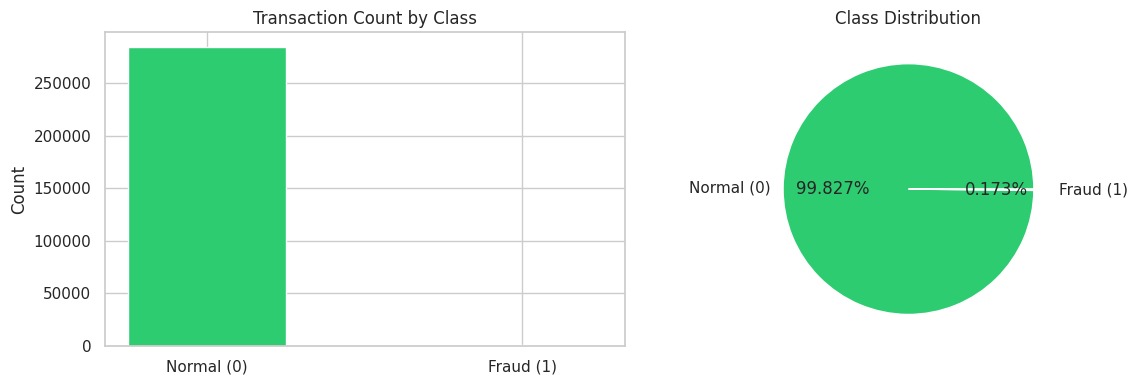

In [4]:
# --- Phan phoi nhan ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Class'].value_counts()
axes[0].bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['#2ecc71', '#e74c3c'], width=0.5)
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['Normal (0)', 'Fraud (1)'],
            autopct='%1.3f%%', colors=['#2ecc71', '#e74c3c'], explode=(0, 0.1))
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.show()

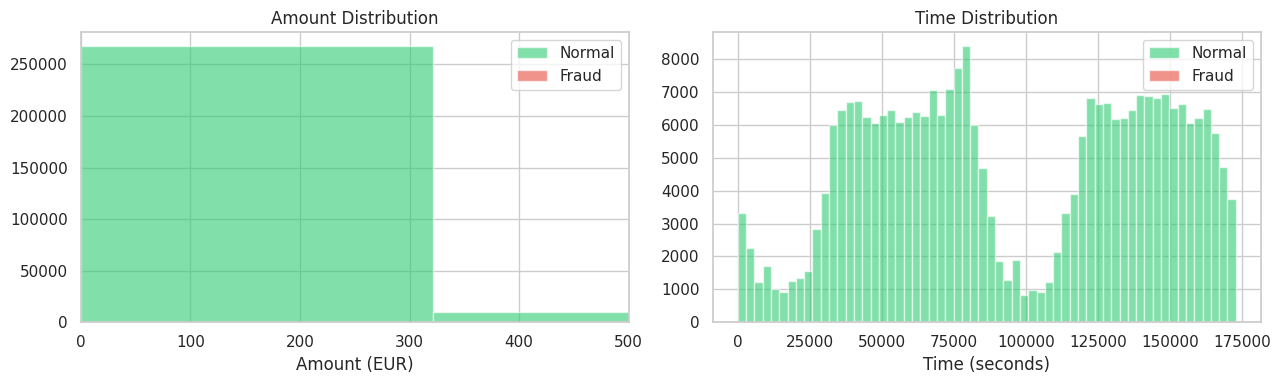

In [5]:
# --- Phan tich Amount va Time ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in zip([0, 1], ['#2ecc71', '#e74c3c']):
    name = 'Normal' if label == 0 else 'Fraud'
    axes[0].hist(df[df['Class'] == label]['Amount'], bins=80, color=color, alpha=0.6, label=name)
    axes[1].hist(df[df['Class'] == label]['Time'],   bins=60, color=color, alpha=0.6, label=name)

axes[0].set_xlim(0, 500)
axes[0].set_title('Amount Distribution')
axes[0].set_xlabel('Amount (EUR)')
axes[0].legend()

axes[1].set_title('Time Distribution')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [7]:
# --- Tien xu ly ---
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Chuan hoa Amount va Time (V1-V28 da qua PCA)
# fit tren train, transform tren test de tranh data leakage
scaler = StandardScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']]  = scaler.transform(X_test[['Amount', 'Time']])

In [8]:
# --- Mo hinh Random Forest ---
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',  # xu ly mat can bang
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [9]:
# --- Danh gia mo hinh ---
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_pred_proba):.4f}')

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.80      0.84      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC : 0.9786
PR-AUC  : 0.8425


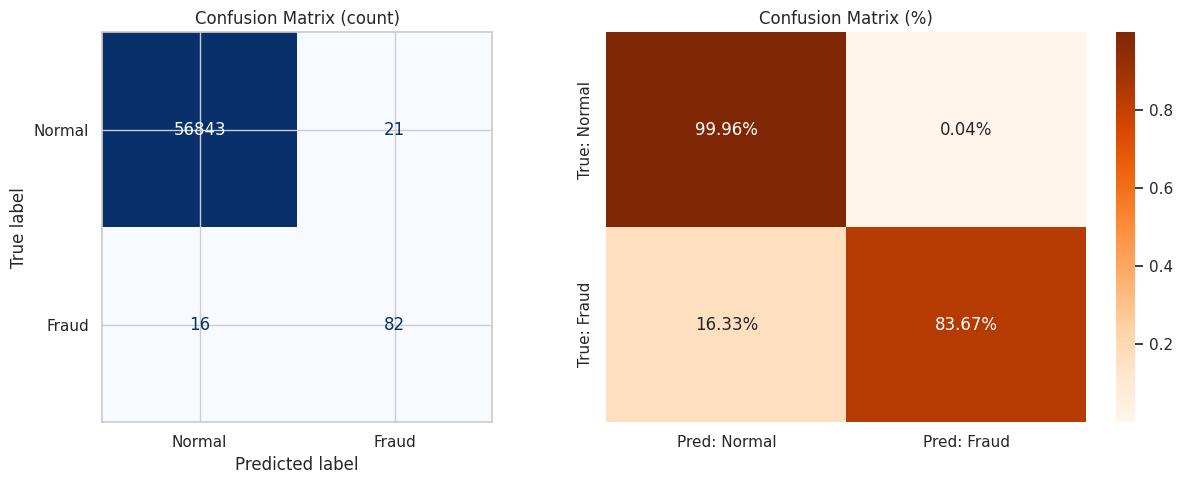

TN=56843  FP=21  FN=16  TP=82


In [10]:
# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix (count)')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_pct, annot=True, fmt='.2%', cmap='Oranges', ax=axes[1],
            xticklabels=['Pred: Normal', 'Pred: Fraud'],
            yticklabels=['True: Normal', 'True: Fraud'])
axes[1].set_title('Confusion Matrix (%)')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

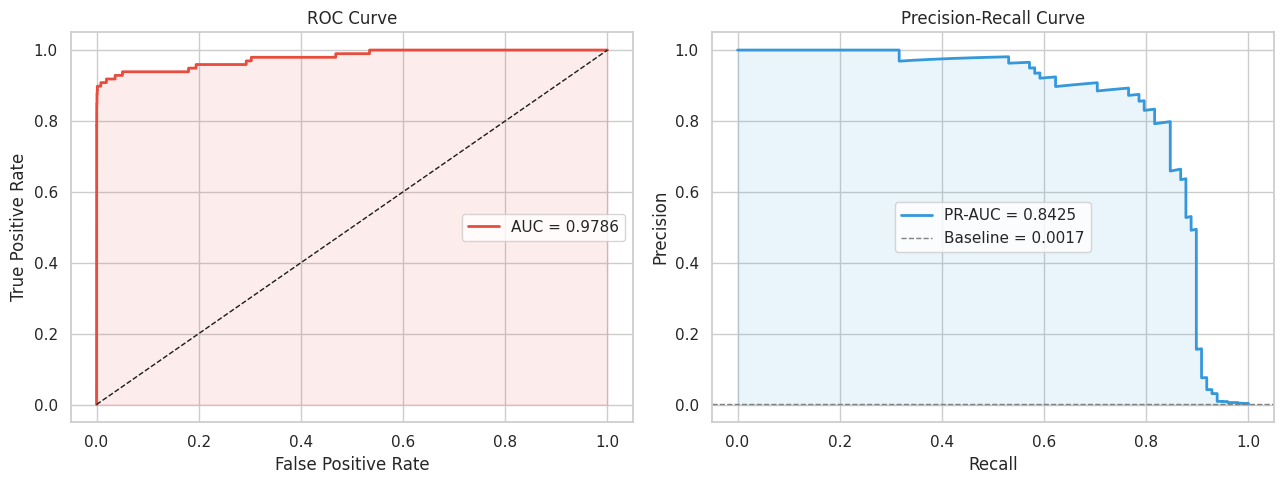

In [11]:
# --- ROC Curve & Precision-Recall Curve ---
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc  = average_precision_score(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
axes[1].plot(rec, prec, color='#3498db', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1,
                label=f'Baseline = {y_test.mean():.4f}')
axes[1].fill_between(rec, prec, alpha=0.1, color='#3498db')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

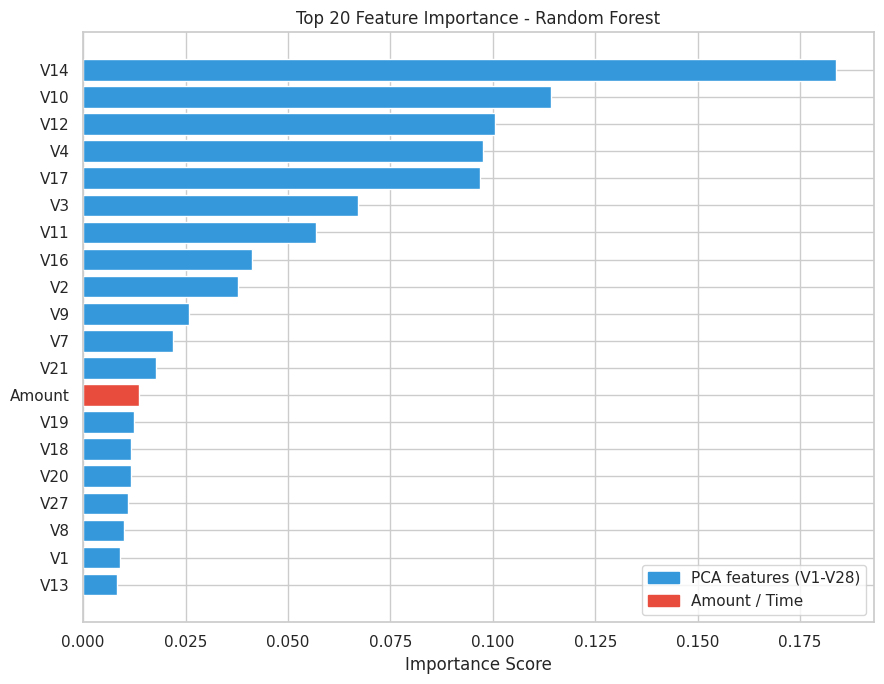

In [12]:
# --- Feature Importance ---
feat_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_feat = feat_df.head(20)
colors   = ['#e74c3c' if f in ['Amount', 'Time'] else '#3498db' for f in top_feat['Feature']]

plt.figure(figsize=(9, 7))
plt.barh(top_feat['Feature'][::-1], top_feat['Importance'][::-1],
         color=colors[::-1], edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importance - Random Forest')
plt.legend(handles=[
    Patch(color='#3498db', label='PCA features (V1-V28)'),
    Patch(color='#e74c3c', label='Amount / Time')
])
plt.tight_layout()
plt.show()

In [17]:
metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1-score' : f1_score(y_test, y_pred),
}

metrics_df = pd.DataFrame(metrics.items(), columns=['Metric', 'Score'])
metrics_df['Score'] = metrics_df['Score'].round(4)
print(metrics_df.to_string(index=False))

   Metric  Score
 Accuracy 0.9994
Precision 0.7961
   Recall 0.8367
 F1-score 0.8159


In [14]:
# Best threshold F1
thresholds = np.arange(0.1, 0.6, 0.01)
scores = [(t, f1_score(y_test, (y_pred_proba >= t).astype(int))) for t in thresholds]
best_t, best_f1 = max(scores, key=lambda x: x[1])

y_pred_tuned = (y_pred_proba >= best_t).astype(int)

print(f'Best threshold: {best_t:.2f}')
print()

metrics_tuned = {
    'Accuracy' : accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall'   : recall_score(y_test, y_pred_tuned),
    'F1-score' : f1_score(y_test, y_pred_tuned),
}
df_tuned = pd.DataFrame(metrics_tuned.items(), columns=['Metric', 'Score'])
df_tuned['Score'] = df_tuned['Score'].round(4)
print(df_tuned.to_string(index=False))

Best threshold: 0.48

   Metric  Score
 Accuracy 0.9994
Precision 0.7905
   Recall 0.8469
 F1-score 0.8177


In [15]:
# using SMOTE
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_sm, y_train_sm)

y_pred_sm       = rf_smote.predict(X_test)
y_pred_proba_sm = rf_smote.predict_proba(X_test)[:, 1]

metrics_sm = {
    'Accuracy' : accuracy_score(y_test, y_pred_sm),
    'Precision': precision_score(y_test, y_pred_sm),
    'Recall'   : recall_score(y_test, y_pred_sm),
    'F1-score' : f1_score(y_test, y_pred_sm),
}
df_sm = pd.DataFrame(metrics_sm.items(), columns=['Metric', 'Score'])
df_sm['Score'] = df_sm['Score'].round(4)
print(df_sm.to_string(index=False))

   Metric  Score
 Accuracy 0.9976
Precision 0.4118
   Recall 0.8571
 F1-score 0.5563


In [18]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='aucpr',
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb       = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

metrics_xgb = {
    'Accuracy' : accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall'   : recall_score(y_test, y_pred_xgb),
    'F1-score' : f1_score(y_test, y_pred_xgb),
}
df_xgb = pd.DataFrame(metrics_xgb.items(), columns=['Metric', 'Score'])
df_xgb['Score'] = df_xgb['Score'].round(4)
print(f'ROC-AUC : {roc_auc_score(y_test, y_pred_proba_xgb):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_pred_proba_xgb):.4f}')
print()
print(df_xgb.to_string(index=False))

ROC-AUC : 0.9769
PR-AUC  : 0.8680

   Metric  Score
 Accuracy 0.9994
Precision 0.8058
   Recall 0.8469
 F1-score 0.8259
